### Portfolio Optimization: CAPM, Sharp Ratio

In [ ]:
%pip install --upgrade jinja2

  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
Using cached jinja2-3.1.6-py3-none-any.whl (134 kB)
  Attempting uninstall: jinja2
    Found existing installation: Jinja2 3.0.3
    Uninstalling Jinja2-3.0.3:
      Successfully uninstalled Jinja2-3.0.3
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In this notebook, the historical stock price data of 20 companies from the period between 2020 to 2024 were initially gathered. The goal was to analyze the performance of these stocks and identify the most promising ones for constructing an optimal investment portfolio. The analysis began with the correlation of the data to understand the relationships between the stocks. Subsequently, the expected returns for each stock were calculated using the Capital Asset Pricing Model (CAPM), which provided insights into the potential future performance of the stocks in relation to the market.

Following the return calculations, five stocks were selected based on their expected returns and their correlations with other stocks, ensuring that the selected stocks were well-diversified and had the best potential for inclusion in an investment portfolio.

To optimize the portfolio further, a Monte Carlo simulation was applied. This allowed for the exploration of various portfolio combinations and their risk-return profiles. By calculating the Sharpe ratio for each simulation, we were able to identify the portfolio that maximized the risk-adjusted return. Additionally, the Efficient Frontier was derived, representing the set of optimal portfolios that offer the highest expected return for a given level of risk.

Finally, using the results of the Monte Carlo simulation and the Efficient Frontier analysis, the optimal weights for each of the selected stocks in the portfolio were determined. This process ensures that the portfolio is well-balanced, with the best possible allocation of assets to achieve an optimal risk-return tradeoff.

In [1]:
import numpy as np 
import pandas as pd 
import yfinance as yf
import matplotlib.pyplot as plt

In [30]:
stocks = ['AAPL', 'MSFT', 'AMZN', 'GOOGL', 'TSLA', 'META', 'NVDA', 'PYPL', 'V', 'JNJ', 'WMT',
          'PG', 'XOM', 'BAC', 'DIS', 'NFLX', 'ADBE', 'PFE', 'INTC', 'KO']
stocks_data = yf.download(stocks, start = '2020-01-01', end = '2024-12-31')['Close']
stocks_data

C:\Users\user\AppData\Local\Temp\ipykernel_12028\1790091307.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stocks_data = yf.download(stocks, start = '2020-01-01', end = '2024-12-31')['Close']
[*********************100%***********************]  20 of 20 completed


Ticker,AAPL,ADBE,AMZN,BAC,DIS,GOOGL,INTC,JNJ,KO,META,MSFT,NFLX,NVDA,PFE,PG,PYPL,TSLA,V,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,
2020-01-02,72.468262,334.429993,94.900497,30.920332,145.769897,67.965233,53.666470,123.290192,46.066414,208.494690,152.505676,32.980999,5.971409,27.955412,106.273239,110.494568,28.684000,183.186234,36.508095,53.661728
2020-01-03,71.763710,331.809998,93.748497,30.278326,144.097763,67.609680,53.013718,121.862778,45.815098,207.391479,150.606705,32.590000,5.875831,27.805426,105.558495,108.509155,29.534000,181.729355,36.185806,53.230305
2020-01-06,72.335548,333.709991,95.143997,30.234947,143.261719,69.411758,52.863777,121.710747,45.798344,211.297409,150.995956,33.583000,5.900473,27.769705,105.704872,109.915901,30.102667,181.336365,36.112144,53.639015
2020-01-07,71.995361,333.390015,95.343002,30.035412,143.310898,69.277687,51.981674,122.454025,45.446491,211.754578,149.619293,33.075001,5.971908,27.676859,105.050407,109.417053,31.270666,180.857147,35.777557,53.200031
2020-01-08,73.153496,337.869995,94.598503,30.339056,143.015808,69.770782,52.016960,122.437103,45.530273,213.901352,152.002472,33.925999,5.983109,27.898266,105.498207,111.562096,32.809334,183.953033,35.654797,52.397755
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-23,254.120682,446.739990,225.059998,43.119404,110.926964,193.997543,20.200001,140.955261,61.017918,598.452087,432.062775,91.144997,139.639572,24.907780,163.782852,86.699577,430.600006,314.982819,89.675789,102.536774
2024-12-24,257.037506,447.940002,229.050003,43.600807,112.082031,195.472717,20.400000,141.518051,61.467869,606.333740,436.112885,93.211998,140.189468,24.935757,164.591476,88.046463,462.279999,318.388611,91.988411,102.633224
2024-12-26,257.853790,450.160004,227.050003,43.767815,112.072083,194.964386,20.440001,141.256042,61.203762,601.943970,434.901825,92.414001,139.899521,24.767899,165.780075,87.936714,454.130005,318.646759,92.097588,102.720032


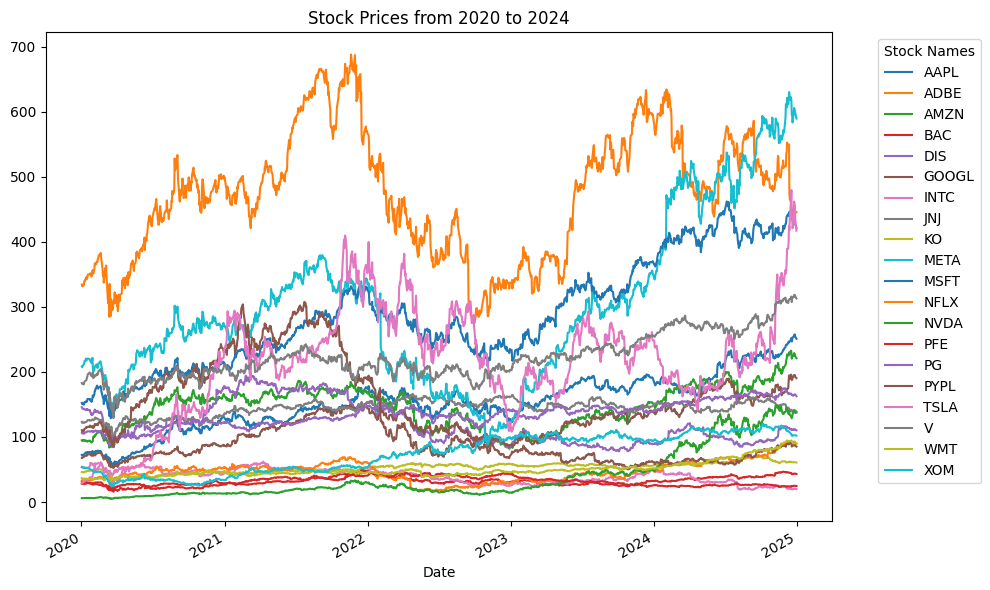

In [31]:
stocks_data.plot(figsize=(10, 6))
plt.title("Stock Prices from 2020 to 2024")
plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1), title="Stock Names")
plt.tight_layout()
plt.show()

#### Correlation
- Using Logarithmic return

In [32]:
stocks_data_log_return = np.log(stocks_data / stocks_data.shift())
stocks_data_log_return

Ticker,AAPL,ADBE,AMZN,BAC,DIS,GOOGL,INTC,JNJ,KO,META,MSFT,NFLX,NVDA,PFE,PG,PYPL,TSLA,V,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,
2020-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-03,-0.009770,-0.007865,-0.012213,-0.020982,-0.011537,-0.005245,-0.012238,-0.011645,-0.005470,-0.005305,-0.012530,-0.011926,-0.016135,-0.005380,-0.006748,-0.018132,0.029203,-0.007985,-0.008867,-0.008072
2020-01-06,0.007937,0.005710,0.014776,-0.001434,-0.005819,0.026305,-0.002832,-0.001248,-0.000366,0.018658,0.002581,0.030014,0.004185,-0.001285,0.001386,0.012881,0.019072,-0.002165,-0.002038,0.007649
2020-01-07,-0.004714,-0.000959,0.002089,-0.006621,0.000343,-0.001933,-0.016827,0.006088,-0.007712,0.002161,-0.009159,-0.015242,0.012034,-0.003349,-0.006211,-0.004549,0.038067,-0.002646,-0.009308,-0.008218
2020-01-08,0.015958,0.013348,-0.007839,0.010059,-0.002061,0.007092,0.000679,-0.000138,0.001842,0.010087,0.015803,0.025404,0.001874,0.007968,0.004254,0.019415,0.048033,0.016973,-0.003437,-0.015195
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-23,0.003060,-0.000962,0.000622,-0.006359,-0.005639,0.016683,0.034243,0.005522,-0.002721,0.024640,-0.003097,0.002637,0.036232,0.013190,0.000298,-0.002643,0.022404,-0.001543,-0.020703,0.004053
2024-12-24,0.011413,0.002683,0.017573,0.011103,0.010359,0.007575,0.009852,0.003985,0.007347,0.013084,0.009330,0.022425,0.003930,0.001123,0.004925,0.015416,0.070991,0.010755,0.025462,0.000940
2024-12-26,0.003171,0.004944,-0.008770,0.003823,-0.000089,-0.002604,0.001959,-0.001853,-0.004306,-0.007266,-0.002781,-0.008598,-0.002070,-0.006754,0.007196,-0.001247,-0.017787,0.000810,0.001186,0.000845


In [33]:
correlation_stocks = stocks_data_log_return.corr()
correlation_stocks.style.background_gradient(cmap='coolwarm')

Ticker,AAPL,ADBE,AMZN,BAC,DIS,GOOGL,INTC,JNJ,KO,META,MSFT,NFLX,NVDA,PFE,PG,PYPL,TSLA,V,WMT,XOM
Ticker,,,,,,,,,,,,,,,,,,,,
AAPL,1.000000,0.618734,0.594726,0.417812,0.442661,0.652798,0.485855,0.375249,0.444248,0.560247,0.750878,0.450652,0.614594,0.287737,0.428445,0.539188,0.492377,0.586010,0.363196,0.288470
ADBE,0.618734,1.000000,0.604681,0.318781,0.388402,0.624798,0.451810,0.245333,0.316084,0.546716,0.723733,0.482849,0.620859,0.215731,0.324398,0.542011,0.410047,0.526638,0.299039,0.178321
AMZN,0.594726,0.604681,1.000000,0.287107,0.404303,0.649915,0.437141,0.180077,0.223885,0.605986,0.680125,0.529344,0.586697,0.167992,0.232653,0.521356,0.436442,0.409066,0.297364,0.136036
BAC,0.417812,0.318781,0.287107,1.000000,0.581577,0.412615,0.408903,0.410057,0.520097,0.314586,0.425422,0.190229,0.322160,0.322904,0.380253,0.390374,0.285910,0.602192,0.255254,0.598810
DIS,0.442661,0.388402,0.404303,0.581577,1.000000,0.454259,0.390054,0.292859,0.443897,0.380683,0.471225,0.358476,0.393126,0.237076,0.306933,0.435847,0.321009,0.580995,0.237564,0.446247
GOOGL,0.652798,0.624798,0.649915,0.412615,0.454259,1.000000,0.463023,0.297979,0.372176,0.636804,0.747878,0.437761,0.600564,0.255377,0.334810,0.509475,0.406032,0.548466,0.294380,0.264069
INTC,0.485855,0.451810,0.437141,0.408903,0.390054,0.463023,1.000000,0.266100,0.309273,0.399023,0.530642,0.332863,0.483347,0.254675,0.310675,0.393746,0.339028,0.420256,0.265126,0.286293
JNJ,0.375249,0.245333,0.180077,0.410057,0.292859,0.297979,0.266100,1.000000,0.589849,0.195318,0.377301,0.113464,0.149729,0.541475,0.618026,0.240771,0.086649,0.452239,0.399912,0.301049
KO,0.444248,0.316084,0.223885,0.520097,0.443897,0.372176,0.309273,0.589849,1.000000,0.225424,0.436917,0.136371,0.221846,0.427203,0.655466,0.254706,0.171955,0.564686,0.398441,0.431214


In [34]:
upper_triangle = correlation_stocks.where(np.triu(np.ones(correlation_stocks.shape), k=1).astype(bool))

correlation_sums = upper_triangle.sum(axis=1)

least_correlated_stocks = correlation_sums.nsmallest(10).index

selected_stockes = stocks_data_log_return[least_correlated_stocks]

print("Selected Stocks:")
print(least_correlated_stocks)

Selected Stocks:
Index(['XOM', 'WMT', 'TSLA', 'V', 'PYPL', 'PFE', 'PG', 'NFLX', 'NVDA', 'META'], dtype='object', name='Ticker')


#### CAPM
$$ER_i = R_f+\beta_{i}({ER}_m-R_f)$$
- ${ER}_i$: Expected return from investment
- $R_f$: Risk free return
- $\beta_{i}$: The beta of the investment
- $({ER}_m-R_f)$: Market risk premium

In [35]:
sel_stockes = list(least_correlated_stocks)
selected_list = sel_stockes + ["^GSPC"]
data_stocks = yf.download(selected_list, start = '2020-01-01', end = '2024-12-31')['Close']
data_stocks.rename(columns={'^GSPC': 'SP500'}, inplace=True)

data_stocks

C:\Users\user\AppData\Local\Temp\ipykernel_12028\1346192174.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data_stocks = yf.download(selected_list, start = '2020-01-01', end = '2024-12-31')['Close']
[*********************100%***********************]  11 of 11 completed


Ticker,META,NFLX,NVDA,PFE,PG,PYPL,TSLA,V,WMT,XOM,SP500
Date,,,,,,,,,,,
2020-01-02,208.494690,32.980999,5.971409,27.955412,106.273239,110.494568,28.684000,183.186234,36.508095,53.661728,3257.850098
2020-01-03,207.391479,32.590000,5.875831,27.805426,105.558495,108.509155,29.534000,181.729355,36.185806,53.230305,3234.850098
2020-01-06,211.297409,33.583000,5.900473,27.769705,105.704872,109.915901,30.102667,181.336365,36.112144,53.639015,3246.280029
2020-01-07,211.754578,33.075001,5.971908,27.676859,105.050407,109.417053,31.270666,180.857147,35.777557,53.200031,3237.179932
2020-01-08,213.901352,33.925999,5.983109,27.898266,105.498207,111.562096,32.809334,183.953033,35.654797,52.397755,3253.050049
...,...,...,...,...,...,...,...,...,...,...,...
2024-12-23,598.452087,91.144997,139.639572,24.907780,163.782852,86.699577,430.600006,314.982819,89.675789,102.536774,5974.069824
2024-12-24,606.333740,93.211998,140.189468,24.935757,164.591476,88.046463,462.279999,318.388611,91.988411,102.633224,6040.040039
2024-12-26,601.943970,92.414001,139.899521,24.767899,165.780075,87.936714,454.130005,318.646759,92.097588,102.720032,6037.589844


In [36]:
data_stocks_log_return = np.log(data_stocks / data_stocks.shift())
covariance = data_stocks_log_return.cov()
covariance

Ticker,META,NFLX,NVDA,PFE,PG,PYPL,TSLA,V,WMT,XOM,SP500
Ticker,,,,,,,,,,,
META,0.000819,0.000411,0.000516,0.000090,0.000091,0.000426,0.000403,0.000219,0.000090,0.000098,0.000239
NFLX,0.000411,0.000872,0.000469,0.000057,0.000070,0.000388,0.000449,0.000157,0.000095,0.000062,0.000188
NVDA,0.000516,0.000469,0.001137,0.000087,0.000105,0.000486,0.000678,0.000284,0.000118,0.000137,0.000320
PFE,0.000090,0.000057,0.000087,0.000298,0.000090,0.000097,0.000060,0.000105,0.000064,0.000092,0.000099
PG,0.000091,0.000070,0.000105,0.000090,0.000174,0.000101,0.000060,0.000105,0.000095,0.000065,0.000099
PYPL,0.000426,0.000388,0.000486,0.000097,0.000101,0.000813,0.000511,0.000254,0.000105,0.000136,0.000242
TSLA,0.000403,0.000449,0.000678,0.000060,0.000060,0.000511,0.001782,0.000268,0.000096,0.000140,0.000291
V,0.000219,0.000157,0.000284,0.000105,0.000105,0.000254,0.000268,0.000308,0.000072,0.000173,0.000185
WMT,0.000090,0.000095,0.000118,0.000064,0.000095,0.000105,0.000096,0.000072,0.000202,0.000055,0.000085


In [37]:
variance = data_stocks_log_return['SP500'].var()
variance

0.00018236809514221987

In [38]:
beta = covariance['SP500'] / variance
beta

Ticker
META     1.309395
NFLX     1.028162
NVDA     1.753683
PFE      0.540240
PG       0.543072
PYPL     1.326406
TSLA     1.594365
V        1.011936
WMT      0.464099
XOM      0.836521
SP500    1.000000
Name: SP500, dtype: float64

In [39]:
risk_free_return = 0.042
market_return = 0.1
expected_return = risk_free_return + beta*(market_return - risk_free_return)
expected_return

Ticker
META     0.117945
NFLX     0.101633
NVDA     0.143714
PFE      0.073334
PG       0.073498
PYPL     0.118932
TSLA     0.134473
V        0.100692
WMT      0.068918
XOM      0.090518
SP500    0.100000
Name: SP500, dtype: float64

Among these stocks, 6 companies with expected returns greater than 1 are selected for the portfolio. These stocks are:

1. META
2. NFLX
3. NVDA
4. PYPL
5. TSLA
6. V

##### Sharp Ration and Monte Carlo
**Sharpe ratio:** It measures the average return on investment compared to possible risks. In other words, it is worth investing in this market or not. It expresses the ratio of return to risk.

- Sharp ratio is acceptable if it is above 1.<br>
- If it is above 2, it is very good.<br>
- And if it is below 1, it does not reach the minimum sufficient return

$$SR = \frac{R_p-R_f}{\sigma_p}$$


$R_p$: return of portfolio

$R_f$: risk free return

$\sigma_p$: standard deviation of portfolio

**Monte Carlo**
To find out what the optimal proportions are for stocks in a portfolio, we use the Monte Carlo method.

In [44]:
final_Stocks = ['META', 'NFLX', 'NVDA', 'PYPL', 'TSLA', 'V']
data = data_stocks_log_return[final_Stocks]
data

Ticker,META,NFLX,NVDA,PYPL,TSLA,V
Date,,,,,,
2020-01-02,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-03,-0.005305,-0.011926,-0.016135,-0.018132,0.029203,-0.007985
2020-01-06,0.018658,0.030014,0.004185,0.012881,0.019072,-0.002165
2020-01-07,0.002161,-0.015242,0.012034,-0.004549,0.038067,-0.002646
2020-01-08,0.010087,0.025404,0.001874,0.019415,0.048033,0.016973
...,...,...,...,...,...,...
2024-12-23,0.024640,0.002637,0.036232,-0.002643,0.022404,-0.001543
2024-12-24,0.013084,0.022425,0.003930,0.015416,0.070991,0.010755
2024-12-26,-0.007266,-0.008598,-0.002070,-0.001247,-0.017787,0.000810


In [46]:
n = 25000

weights = np.zeros((n, 6))
exp_returns = np.zeros(n)
exp_volatilities = np.zeros(n)
sharpe_ratios = np.zeros(n)

for i in range(n):
    weight = np.random.random(6)
    weight /= np.sum(weight)
    weights[i] = weight
    
    exp_returns[i] = np.sum(data.mean()*weight)*252
    exp_volatilities[i] = np.sqrt(np.dot(weight.T, np.dot(data.cov()*252, weight)))
    sharpe_ratios[i] = exp_returns[i] / exp_volatilities[i]

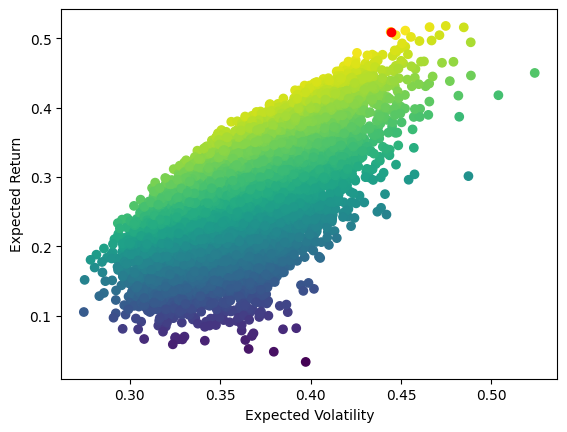

In [47]:
ig, ax = plt.subplots()
ax.scatter(exp_volatilities, exp_returns, c=sharpe_ratios)
ax.scatter(exp_volatilities[sharpe_ratios.argmax()], exp_returns[sharpe_ratios.argmax()], c='r')
ax.set_xlabel("Expected Volatility")
ax.set_ylabel("Expected Return")
plt.show()

The Efficient Frontier represents a set of optimal portfolios that provide the highest expected return for a given level of risk. Based on Markowitz’s Modern Portfolio Theory, it emphasizes diversification to maximize returns while minimizing risk by combining assets with low correlations.

In [48]:
max_sharpe_idx = sharpe_ratios.argmax()
optimal_weights = weights[max_sharpe_idx]

print("Optimal Weights for Each Stock:")
for i, stock in enumerate(final_Stocks):
    print(f"{stock}: {optimal_weights[i]:.4f}")

Optimal Weights for Each Stock:
META: 0.1053
NFLX: 0.0683
NVDA: 0.5578
PYPL: 0.0079
TSLA: 0.2208
V: 0.0398
